# Cluster pilot: what the dimer+trimer dataset contains

`results/cluster_pilot/` is the first run of `asmcmc.data_preparation.cluster_dataset` —
500 UMA-labelled benzene clusters generated to train a Δ-learning AniSOAP correction.
Nothing consumes it yet, so this notebook exists to decide three things before a
production campaign is paid for:

1. **QA** — is the campaign trustworthy?
2. **Content** — what is actually in it, and how much of it is usable pair data?
3. **Target** — how large is `Δ = E_UMA − E_GBQ`, and *where in geometry does it live*?
   That is what sets a fit's weighting.

Sections 2–5 each end pointing at a different sampling knob. **§6 shows they share one
cause and that most of those knobs are the wrong lever** — read it before acting on any of
them.

The analysis functions live in `asmcmc/data_preparation/cluster_analysis.py` (tested in
`tests/test_cluster_analysis.py`) rather than in these cells, because the Δ fit will need
the same pair unpacking.

**Nothing here calls an MLIP.** Every quantity is read from the stored frames or recomputed
from the GB+Q closed form, so this notebook runs on a laptop without fairchem.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, TwoSlopeNorm

from asmcmc.data_preparation.cluster_analysis import (
    COFACIAL, FAR_SLIPPED, PARALLEL_DISPLACED, T_SHAPED, EV_TO_KCAL,
    gb_invariants, load_campaign, mc_pair_reference, motif_masks,
    pair_records, qa_report, radial_profile, stack_coordinates,
    three_body_records,
)

%matplotlib inline

CAMPAIGN = "../results/cluster_pilot"
# The 100 K herringbone run: the converged HB->SP endpoint (V/mol 96.5 A^3), i.e. the
# geometries the sampler actually asks the potential about.
MC_DB = "../results/validation/100.0_6.324209e-07/herringbone_jittered_2/simulation.db"

# Categorical slots in fixed order (validated default palette, slots 1-3). Assigned by
# entity, never cycled: clusters stay blue and MC stays orange in every figure below.
C_CLUSTER, C_MC, C_ACCENT = "#2a78d6", "#eb6834", "#1baf7a"
GRID = dict(alpha=0.25, linewidth=0.6)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

frames, config = load_campaign(CAMPAIGN)
records = pair_records(frames)
print(f"{len(frames)} frames, generated with:")
for key in ("n_configs", "n_shards", "seed0", "model", "decomposition", "trimer_fraction"):
    print(f"  {key:18s} {config[key]}")
for key, value in config["settings"].items():
    print(f"  settings.{key:9s} {value}")

500 frames, generated with:
  n_configs          500
  n_shards           4
  seed0              20260731
  model              uma-s-1p1
  decomposition      full
  trimer_fraction    0.7
  settings.min_com_distance 3.4
  settings.max_com_distance 15.0
  settings.trimer_max_com_distance 15.0
  settings.min_atom_distance 2.4
  settings.radial_sampling mixture
  settings.rigid     True
  settings.vibration_rms 0.05
  settings.vibration_max_atom 0.1
  settings.compact_probability 0.7
  settings.max_placement_attempts 500


## 1. QA

Integrity first: nothing below is worth reading if the campaign is not sound. The
many-body checks are **exact-arithmetic identities**, not tolerances — the generator
*defines* `three_body_energy` as `E₁₂₃ − Σ E_ij + Σ E_i`, so any nonzero residual means the
stored fields disagree with each other.

The GBQ baseline check is the one that licenses everything in §4: a frame's stored
`gbq_interaction_energy` is summed over the *whole cluster*, so for a trimer it is the sum
of three pairs. Attributing it per pair is only legitimate if a per-pair rebuild reproduces
the stored total.

In [14]:
qa = qa_report(frames, config)

rows = [
    ("frames", f"{qa.n_frames}"),
    ("dimers / trimers", f"{qa.n_dimers} / {qa.n_trimers}"),
    ("labelled pairs", f"{qa.n_pairs}"),
    ("unique (shard, config_index)", "yes" if qa.unique_ids else "NO"),
    ("shard -> seed", ", ".join(f"{k}:{v[0]}" for k, v in qa.shard_seeds.items())),
    ("monomer reference spread (eV)", f"{qa.monomer_energy_spread:.1e}"),
    ("min inter-molecular atom distance (A)", f"{qa.min_atom_distance:.4f}"),
    ("hard-core violations", f"{qa.hard_core_violations}"),
    ("three-body algebra residual (eV)", f"{qa.three_body_max_error:.1e}"),
    ("pair-interaction algebra residual (eV)", f"{qa.pair_algebra_max_error:.1e}"),
    ("GBQ baseline rebuild error (eV)", f"{qa.baseline_max_error:.1e}"),
    ("duplicate configurations", f"{qa.duplicate_signatures}"),
    ("non-finite frames", f"{qa.non_finite_frames}"),
]
width = max(len(r[0]) for r in rows)
for name, value in rows:
    print(f"{name:<{width}}  {value}")

print()
print("PASS" if qa.ok else "FAIL: " + "; ".join(qa.problems))

frames                                  500
dimers / trimers                        156 / 344
labelled pairs                          1188
unique (shard, config_index)            yes
shard -> seed                           0:20260731, 1:20260732, 2:20260733, 3:20260734
monomer reference spread (eV)           0.0e+00
min inter-molecular atom distance (A)   2.4073
hard-core violations                    0
three-body algebra residual (eV)        0.0e+00
pair-interaction algebra residual (eV)  0.0e+00
GBQ baseline rebuild error (eV)         3.6e-16
duplicate configurations                0
non-finite frames                       0

PASS


**Clean.** The hard core holds at 2.4073 Å against a 2.4 Å floor, the rigid monomer
reference is constant to machine zero (as it must be — every molecule is a rotated copy of
one geometry), and both many-body identities are exactly zero rather than merely small.

## 2. What the dataset actually contains

**The headline: this is 1188 pair samples, not 500.**

Every trimer stores `pair_interaction_energies` computed by *genuine MLIP calls* on its
three 2-molecule subsets — `energy_decomposition` evaluates each pair to build the
three-body term, and those pair energies are kept. So 156 dimers + 344 trimers yield
`156 + 3×344 = 1188` labelled pair interaction energies.

That is a 7.6× multiplier on the apparent dataset size.

**It does not, however, make trimers the cheaper source of pair labels — the opposite.**
With `rigid=True` the monomer reference is one shared constant, so a dimer costs **1 MLIP
call for 1 pair label**, while a trimer costs **1 cluster call + 3 pair-subset calls = 4
for 3 labels**. That is 1.00 against 1.33 calls per label: dimers win. The trimer's extra
purchase is the three-body term alone, which §5 measures at 0.021 kcal/mol.

frames                     500
pair labels                1188
  from sampled dimers      156
  from trimer subsets      1032
multiplier                 2.38 pairs per frame


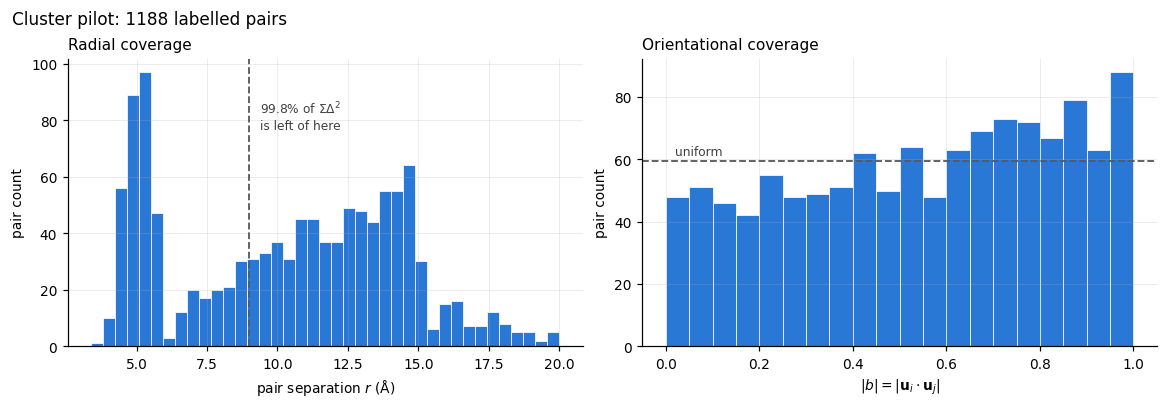

In [15]:
from_dimers = (records["n_molecules"] == 2).sum()
from_trimers = (records["n_molecules"] == 3).sum()

print(f"frames                     {len(frames)}")
print(f"pair labels                {len(records['r'])}")
print(f"  from sampled dimers      {from_dimers}")
print(f"  from trimer subsets      {from_trimers}")
print(f"multiplier                 {len(records['r']) / len(frames):.2f} pairs per frame")

abs_b, a_hi, _ = gb_invariants(records)

fig, (ax_r, ax_b) = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)

ax_r.hist(records["r"], bins=np.linspace(3.4, 20, 40), color=C_CLUSTER, edgecolor="white",
          linewidth=0.5)
ax_r.axvline(9.0, color="0.35", ls="--", lw=1.2)
ax_r.annotate("99.8% of $\\Sigma\\Delta^2$\nis left of here", xy=(9.0, 0.80),
              xycoords=("data", "axes fraction"), xytext=(7, 0), textcoords="offset points",
              ha="left", va="center", fontsize=8, color="0.25")
ax_r.set_xlabel("pair separation $r$ ($\\mathrm{\\AA}$)")
ax_r.set_ylabel("pair count")
ax_r.set_title("Radial coverage", fontsize=10, loc="left")

ax_b.hist(abs_b, bins=np.linspace(0, 1, 21), color=C_CLUSTER, edgecolor="white", linewidth=0.5)
ax_b.axhline(len(abs_b) / 20, color="0.35", ls="--", lw=1.2)
ax_b.annotate("uniform", xy=(0.02, len(abs_b) / 20), xytext=(0, 4), textcoords="offset points",
              fontsize=8, color="0.25")
ax_b.set_xlabel("$|b| = |\\mathbf{u}_i \\cdot \\mathbf{u}_j|$")
ax_b.set_ylabel("pair count")
ax_b.set_title("Orientational coverage", fontsize=10, loc="left")

fig.suptitle("Cluster pilot: 1188 labelled pairs", fontsize=11, x=0.005, ha="left")
plt.show()

Two artifacts are visible in the left panel and both are fixable knobs, not noise:

- **A notch at 6–7 Å.** The `mixture` sampler draws its compact component from a truncated
  normal capped at `min(6.0, hi)`, and the volume-uniform component rarely lands just above
  it. The bin holds 26 pairs against 132 and 169 in its neighbours.
- **A long tail.** 53% of pairs sit in 9–15 Å and another 11% beyond 15 Å (trimers place
  the third molecule relative to *either* of the first two, so 1–3 separations can exceed
  the nominal ceiling).

The `|b|` histogram is mildly skewed toward parallel rather than flat, which is worth
noting but is second-order next to the motif gap in §4.

## 3. Coverage against what the sampler actually visits

The dataset exists because the condensed-phase training set is orientationally degenerate —
1–2 molecule cells make every self-image pair exactly parallel. The test that matters is
therefore not "is the cluster set diverse" in the abstract, but **does it cover the pair
geometries the MC actually visits**.

The reference is the converged 100 K herringbone run (the HB→SP endpoint, V/mol 96.5 Å³),
reduced to the same `(r, |b|, a_hi)` invariants. Reading the maps: cofacial stacking is
`a_hi ≈ 1, |b| ≈ 1`; parallel-displaced is intermediate `a_hi` with `|b| ≈ 1`; T-shaped is
`|b| ≈ 0`.

In [16]:
mc = mc_pair_reference(MC_DB, n_frames=20, cutoff=15.0)
mc_records = {**mc, "n_molecules": np.full(len(mc["r"]), 2)}
mc_b, mc_a_hi, _ = gb_invariants(mc_records)

print(f"MC reference: {len(mc['r'])} pairs from {mc['n_frames']} frames")
print()
print(f"{'shell (A)':<12}{'clusters':>12}{'MC':>10}")
for lo, hi in [(3.4, 5), (5, 6), (6, 7), (7, 9), (9, 15)]:
    c = ((records["r"] >= lo) & (records["r"] < hi)).mean()
    m = ((mc["r"] >= lo) & (mc["r"] < hi)).mean()
    print(f"{lo:>4.1f}-{hi:<7.1f}{100*c:>11.1f}%{100*m:>9.1f}%")

MC reference: 1168680 pairs from 20 frames

shell (A)       clusters        MC
 3.4-5.0           11.1%      2.2%
 5.0-6.0           14.2%      5.3%
 6.0-7.0            2.2%      2.4%
 7.0-9.0            8.5%     10.7%
 9.0-15.0          52.5%     79.4%


**The tail is not oversampled relative to a bulk census — it is undersampled.** 53% of
cluster pairs sit beyond 9 Å against **79%** for the MC frame. The module docstring's
argument stands: in a real frame the >9 Å shell is populous and carries ~9% of cohesion.

So the case for tilting the budget toward short range cannot be "the tail is wasted." It
has to rest on where Δ lives, which is §4.

A caveat governs how the maps below must be read. There are **1188 cluster pairs against
~1.2M MC pairs**, so on a fine grid most empty cluster bins are empty from *sample size*,
not from a real gap — a zero-count "uncovered" map would mostly measure how small the
pilot is. Two things follow: the bins are kept coarse (≈8 pairs per bin on average), and
the third panel is a **density ratio**, which is invariant to the sample sizes because both
sides are normalised first.

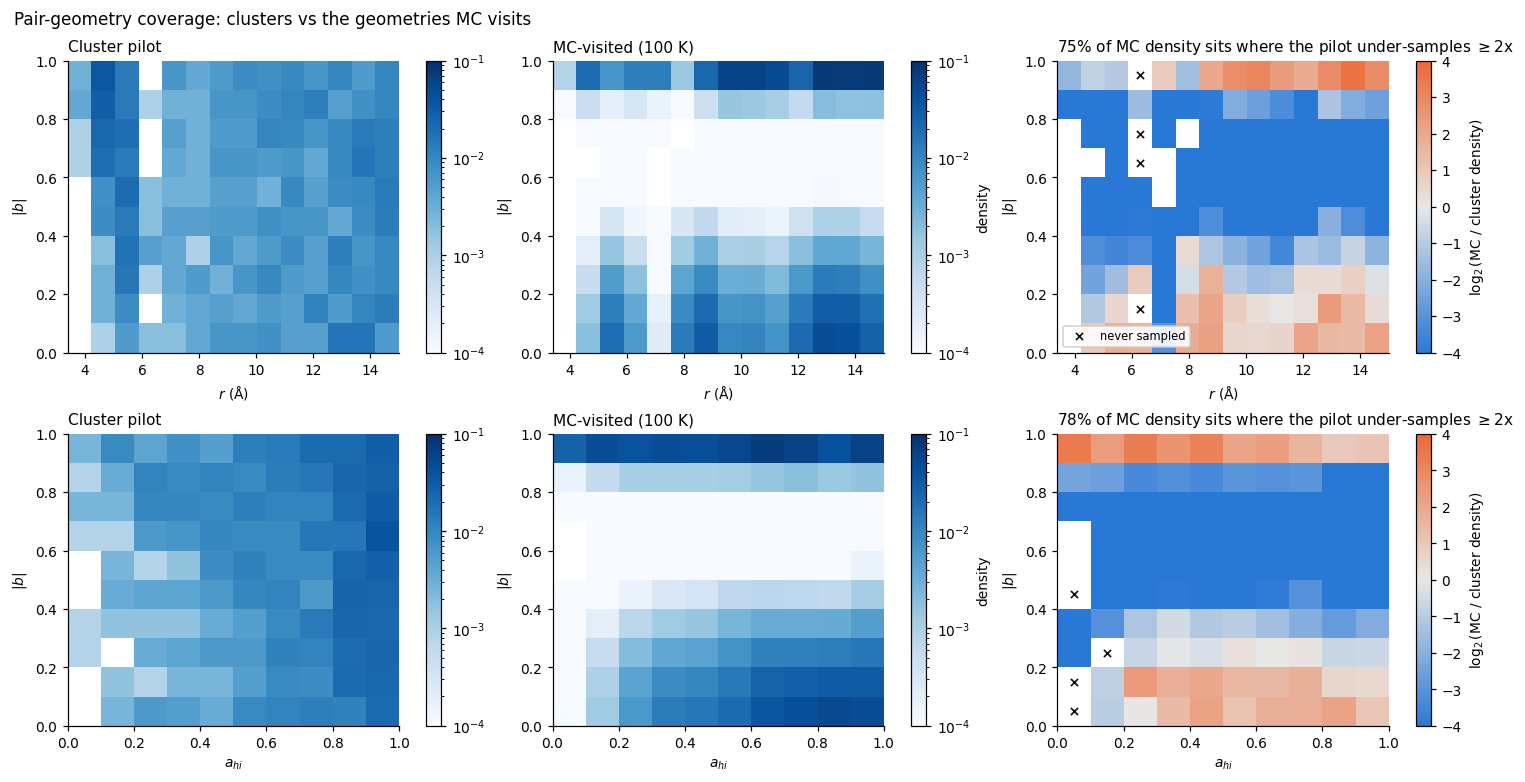

In [17]:
def density(x, y, x_edges, y_edges):
    counts, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    return (counts / counts.sum()).T, counts.T


# Coarse on purpose: 1188 pairs over ~140 bins averages ~8.5 per bin, so occupancy is
# meaningful. A 33x25 grid would put the pilot below 1.5 per bin and the map would show
# sampling noise rather than coverage.
r_edges = np.linspace(3.4, 15.0, 15)
b_edges = np.linspace(0.0, 1.0, 11)
a_edges = np.linspace(0.0, 1.0, 11)

# Diverging: two hues with a neutral midpoint, because the ratio has a meaningful zero
# (log2 = 0 means the pilot samples this cell exactly as often as MC visits it).
ratio_cmap = LinearSegmentedColormap.from_list(
    "cluster_mc", [C_CLUSTER, "#e8e8e6", C_MC]
)

fig, axs = plt.subplots(2, 3, figsize=(13.5, 7.0), constrained_layout=True)
norm = LogNorm(vmin=1e-4, vmax=1e-1)
ratio_norm = TwoSlopeNorm(vmin=-4, vcenter=0.0, vmax=4)

panels = [
    (0, records["r"], abs_b, mc["r"], mc_b, r_edges, b_edges,
     "$r$ ($\\mathrm{\\AA}$)", "$|b|$"),
    (1, a_hi, abs_b, mc_a_hi, mc_b, a_edges, b_edges, "$a_{hi}$", "$|b|$"),
]

for row, x_c, y_c, x_m, y_m, xe, ye, xlabel, ylabel in panels:
    d_c, n_c = density(x_c, y_c, xe, ye)
    d_m, n_m = density(x_m, y_m, xe, ye)

    # Sequential magnitude -> one hue, light to dark. Never a rainbow.
    for ax, data, title in [
        (axs[row, 0], d_c, "Cluster pilot"),
        (axs[row, 1], d_m, "MC-visited (100 K)"),
    ]:
        im = ax.pcolormesh(xe, ye, np.where(data > 0, data, np.nan), cmap="Blues", norm=norm)
        ax.set_title(title, fontsize=10, loc="left")
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(False)
        fig.colorbar(im, ax=ax, label="density" if title.startswith("MC") else "")

    # log2(MC / cluster): how far the pilot's weighting sits from what MC asks for.
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.log2(np.where(d_m > 0, d_m, np.nan) / np.where(d_c > 0, d_c, np.nan))
    ax = axs[row, 2]
    im = ax.pcolormesh(xe, ye, ratio, cmap=ratio_cmap, norm=ratio_norm)
    # True support gaps: MC goes there, the pilot never did. Meaningful at this bin size.
    gap = (n_c == 0) & (n_m > 0)
    ys, xs = np.nonzero(gap)
    ax.scatter((xe[:-1] + xe[1:])[xs] / 2, (ye[:-1] + ye[1:])[ys] / 2,
               marker="x", s=22, color="#0b0b0b", linewidth=1.1, zorder=4,
               label="never sampled" if row == 0 else None)
    under = 100 * np.nansum(np.where(ratio > 1, d_m, 0))
    ax.set_title(f"{under:.0f}% of MC density sits where the pilot under-samples $\\geq$2x",
                 fontsize=10, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(False)
    if row == 0:
        ax.legend(frameon=True, fontsize=7.5, loc="lower left", framealpha=0.9)
    fig.colorbar(im, ax=ax, label="$\\log_2$(MC / cluster density)")

fig.suptitle("Pair-geometry coverage: clusters vs the geometries MC visits",
             fontsize=11, x=0.005, ha="left")
plt.show()

**Support is essentially complete** — at this bin size there are almost no cells the MC
visits that the pilot never sampled, which is the orientational-degeneracy problem solved.
That was the dataset's founding purpose and it worked.

**Weighting is not matched, and the mismatch has a specific shape: the MC density is
bimodal in `|b|` while the pilot's is nearly flat.** Orange marks cells MC visits more often
than the pilot samples them, and it appears at *both* orientational extremes — the
`|b| ≳ 0.9` band (aligned, stacked pairs) and the `|b| ≲ 0.3` region (edge-on, T-like
pairs). Blue — the pilot oversampling — fills the mid-`|b|` interior between them.

That is exactly what a crystal should look like: the herringbone/slipped-parallel motif is
built from aligned stacks and edge-on contacts, and almost nothing in between. Uniform
random orientations, by contrast, put their measure evenly across `|b|`. Roughly three
quarters of the MC's pair density sits in cells the pilot under-samples by 2× or more.

So the pilot's orientational sampling is not wrong in *support*, but it spends most of its
budget in the orientational middle, which is the region neither the crystal nor (as §4
shows) the Δ target cares about.

## 4. The Δ-learning target

`Δ = E_UMA − E_GBQ` is the function an AniSOAP correction has to learn. Its size and
geometric localisation determine how a fit should be weighted.

In [18]:
profile = radial_profile(records)
delta_kcal = records["delta"] * EV_TO_KCAL

header = f"{'shell (A)':<13}{'n':>6}{'% pairs':>9}{'E_UMA rms':>11}{'D rms':>9}{'D max':>9}{'% of SD^2':>11}"
print(header)
print("-" * len(header))
for row in profile:
    hi = "inf" if not np.isfinite(row["r_hi"]) else f"{row['r_hi']:.1f}"
    print(f"{row['r_lo']:>5.1f}-{hi:<7}{row['count']:>6}{100*row['fraction']:>8.1f}%"
          f"{row['e_uma_rms']:>11.3f}{row['delta_rms']:>9.3f}{row['delta_absmax']:>9.3f}"
          f"{100*row['delta_sq_share']:>10.2f}%")

within_9 = records["r"] <= 9.0
share = (delta_kcal[within_9] ** 2).sum() / (delta_kcal ** 2).sum()
print()
print(f"r <= 9 A holds {within_9.sum()} of {len(records['r'])} pairs "
      f"({100*within_9.mean():.0f}%) and {100*share:.1f}% of the total Delta^2.")
print("(energies in kcal/mol)")

shell (A)         n  % pairs  E_UMA rms    D rms    D max  % of SD^2
--------------------------------------------------------------------
  3.4-5.0       132    11.1%      1.825    1.100    6.892     87.50%
  5.0-6.0       169    14.2%      1.504    0.350    0.815     11.33%
  6.0-7.0        26     2.2%      0.637    0.189    0.368      0.51%
  7.0-9.0       101     8.5%      0.249    0.094    0.282      0.49%
  9.0-15.0      624    52.5%      0.015    0.022    0.094      0.17%
 15.0-inf       136    11.4%      0.000    0.002    0.004      0.00%

r <= 9 A holds 428 of 1188 pairs (36%) and 99.8% of the total Delta^2.
(energies in kcal/mol)


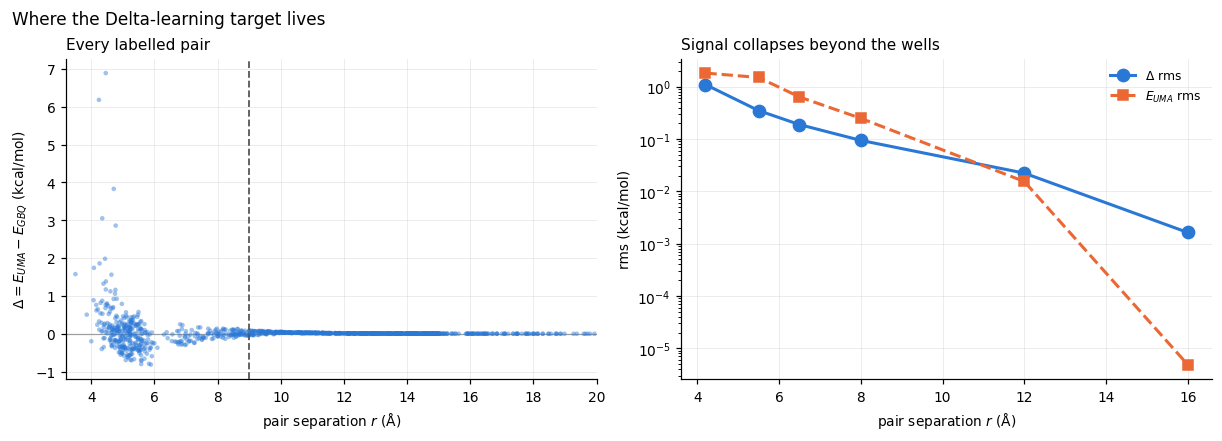

In [19]:
fig, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(11, 3.9), constrained_layout=True)

ax_s.axhline(0, color="0.6", lw=0.8, zorder=1)
ax_s.scatter(records["r"], delta_kcal, s=9, alpha=0.45, color=C_CLUSTER,
             edgecolors="none", zorder=2)
ax_s.axvline(9.0, color="0.35", ls="--", lw=1.2, zorder=3)
ax_s.set_xlabel("pair separation $r$ ($\\mathrm{\\AA}$)")
ax_s.set_ylabel("$\\Delta = E_{UMA} - E_{GBQ}$ (kcal/mol)")
ax_s.set_title("Every labelled pair", fontsize=10, loc="left")
ax_s.set_xlim(3.2, 20)

centres = [0.5 * (row["r_lo"] + min(row["r_hi"], 17.0)) for row in profile]
ax_r.plot(centres, [row["delta_rms"] for row in profile], "o-", color=C_CLUSTER,
          lw=2, ms=8, label="$\\Delta$ rms")
ax_r.plot(centres, [row["e_uma_rms"] for row in profile], "s--", color=C_MC,
          lw=2, ms=7, label="$E_{UMA}$ rms")
ax_r.set_yscale("log")
ax_r.set_xlabel("pair separation $r$ ($\\mathrm{\\AA}$)")
ax_r.set_ylabel("rms (kcal/mol)")
ax_r.set_title("Signal collapses beyond the wells", fontsize=10, loc="left")
ax_r.legend(frameon=False, fontsize=8)

fig.suptitle("Where the Delta-learning target lives", fontsize=11, x=0.005, ha="left")
plt.show()

**99.8% of ΣΔ² sits at r ≤ 9 Å**, in 36% of the pairs. Δ rms falls from 1.100 kcal/mol in
3.4–5 Å to 0.022 in 9–15 Å — a factor of 50. Beyond 15 Å it is 0.002 kcal/mol, i.e. GBQ and
UMA agree to well under any fit's target accuracy.

This is the honest form of the budget argument. The far field is *physically* important
(§3), but it is **already correct under the baseline**, so there is nothing there for a Δ
model to learn. Sampling it densely buys near-zero training signal even though it buys real
physics.

### Motifs, split on slip

Near-parallel pairs are one continuous family: the Cacelli cofacial and parallel-displaced
minima sit at essentially the same stacking height (3.90 vs 3.50 Å) and differ only in
**slip**, the lateral offset — 0.0 Å against 1.6 Å. Slip is therefore the coordinate that
separates them, and `a_hi` is not: PD's `a_hi` is **0.909**, barely below cofacial's 1.0.

`far-slipped` (slip > 3 Å) is reported separately rather than folded into PD because it is
where the baseline is worst, and merging the two would hide it.

In [20]:
masks = motif_masks(records)
order = [COFACIAL, PARALLEL_DISPLACED, FAR_SLIPPED, T_SHAPED]
height, slip = stack_coordinates(records)

print(f"{'motif (3.4-6 A)':<22}{'n':>5}{'E_UMA mean':>13}{'E_UMA min':>12}{'D rms':>9}")
print("-" * 61)
for name in order:
    mask = masks[name]
    if mask.sum() == 0:
        print(f"{name:<22}{0:>5}")
        continue
    e = records["e_uma"][mask] * EV_TO_KCAL
    d = delta_kcal[mask]
    print(f"{name:<22}{mask.sum():>5}{e.mean():>13.3f}{e.min():>12.3f}"
          f"{np.sqrt((d**2).mean()):>9.3f}")
print("(energies in kcal/mol)")

motif (3.4-6 A)           n   E_UMA mean   E_UMA min    D rms
-------------------------------------------------------------
cofacial                 13       -1.338      -2.005    0.174
parallel-displaced       62       -1.528      -2.628    0.451
far-slipped              30       -0.840      -2.093    2.039
T-shaped                 34       -1.696      -2.416    0.321
(energies in kcal/mol)


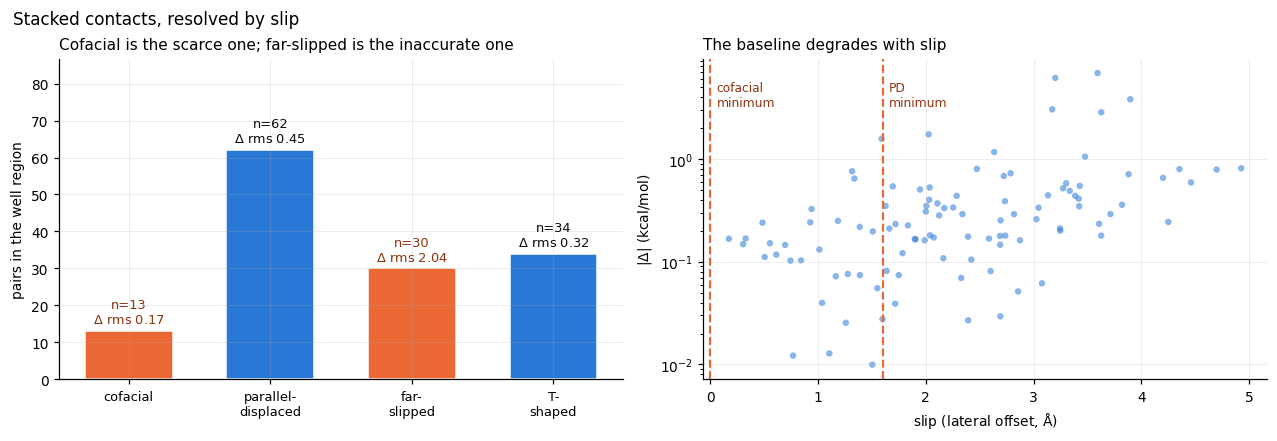

In [21]:
fig, (ax_n, ax_s) = plt.subplots(1, 2, figsize=(11.5, 3.9), constrained_layout=True)

counts = [masks[n].sum() for n in order]
rms = [np.sqrt((delta_kcal[masks[n]] ** 2).mean()) if masks[n].sum() else 0 for n in order]
highlight = [n in (COFACIAL, FAR_SLIPPED) for n in order]

bars = ax_n.bar(range(len(order)), counts,
                color=[C_MC if h else C_CLUSTER for h in highlight],
                edgecolor="white", linewidth=1.0, width=0.62)
for bar, n, r, h in zip(bars, counts, rms, highlight):
    ax_n.annotate(f"n={n}\n$\\Delta$ rms {r:.2f}",
                  xy=(bar.get_x() + bar.get_width() / 2, n), xytext=(0, 5),
                  textcoords="offset points", ha="center", fontsize=8.5,
                  color="#8a3410" if h else "#0b0b0b")
ax_n.set_xticks(range(len(order)))
ax_n.set_xticklabels([n.replace("-", "-\n") for n in order], fontsize=8.5)
ax_n.set_ylabel("pairs in the well region")
ax_n.set_ylim(0, max(counts) * 1.4)
ax_n.set_title("Cofacial is the scarce one; far-slipped is the inaccurate one",
               fontsize=10, loc="left")

parallel = (records["r"] >= 3.4) & (records["r"] < 6.0) & (np.abs(records["b"]) > 0.8)
ax_s.scatter(slip[parallel], np.abs(delta_kcal[parallel]), s=18, alpha=0.55,
             color=C_CLUSTER, edgecolors="none")
for x, label in [(0.0, "cofacial\nminimum"), (1.6, "PD\nminimum")]:
    ax_s.axvline(x, color=C_MC, ls="--", lw=1.4)
    ax_s.annotate(label, xy=(x, 0.93), xycoords=("data", "axes fraction"),
                  xytext=(4, 0), textcoords="offset points", fontsize=8,
                  color="#8a3410", va="top")
ax_s.set_yscale("log")
ax_s.set_xlabel("slip (lateral offset, $\\mathrm{\\AA}$)")
ax_s.set_ylabel("$|\\Delta|$ (kcal/mol)")
ax_s.set_title("The baseline degrades with slip", fontsize=10, loc="left")

fig.suptitle("Stacked contacts, resolved by slip", fontsize=11, x=0.005, ha="left")
plt.show()

**Cofacial is the undersampled motif — n=13 — not parallel-displaced, which gets 62.** The
median slip among near-parallel well pairs is 2.17 Å and only 12% fall below 1 Å, because
reaching a small slip means putting the separation vector nearly along the normals, which
is both a narrow target and the geometry the hard core rejects hardest at short range.

**The baseline degrades with slip**: Δ rms runs 0.17 (cofacial) → 0.45 (PD) → **2.04**
(far-slipped). The far-slipped region is where GB+Q's ellipsoid contact function is least
like the real thing, and it carries the largest correction.

> **Correction.** An earlier version of this notebook cut parallel-displaced as
> `a_hi < 0.6` and reported it as nearly unsampled at n=4 with Δ rms 3.98. That cut cannot
> select the real PD motif at all — its `a_hi` is 0.909 — so PD was being counted as
> cofacial and the "PD" bucket actually held far-slipped pairs. The conclusion about which
> motif is scarce was inverted by it.

## 5. Three-body

69% of the pilot's frames are trimers, each costing 4 MLIP calls instead of 1. §2 already
showed that buys 3 pair labels, so it is not wasted. But the *stated* reason for trimers is
the three-body term — so is that term worth anything as configured?

trimers                             344
three-body rms (kcal/mol)           0.0210
  as a fraction of pair-sum rms     0.0128
  |3b| > 0.05 kcal/mol              4.9% of trimers

compact trimers (all pairs < 7 A)   6 (1.7%)
  their three-body rms              0.0481
  everything else                   0.0202


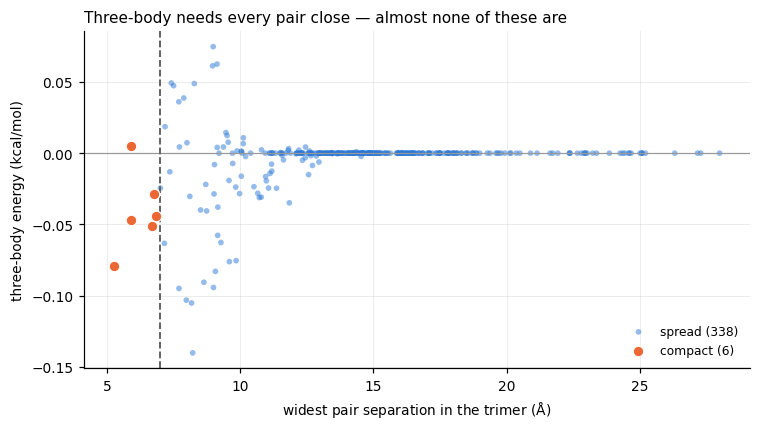

In [22]:
tb = three_body_records(frames)
compact = tb.compact(cutoff=7.0)

print(f"trimers                             {len(tb)}")
print(f"three-body rms (kcal/mol)           {tb.rms():.4f}")
print(f"  as a fraction of pair-sum rms     {tb.relative_rms():.4f}")
print(f"  |3b| > 0.05 kcal/mol              {100*(np.abs(tb.three_body) > 0.05).mean():.1f}% of trimers")
print()
print(f"compact trimers (all pairs < 7 A)   {compact.sum()} ({100*compact.mean():.1f}%)")
print(f"  their three-body rms              {tb.rms(compact):.4f}")
print(f"  everything else                   {tb.rms(~compact):.4f}")

fig, ax = plt.subplots(figsize=(6.8, 3.8), constrained_layout=True)
ax.axhline(0, color="0.6", lw=0.8)
ax.scatter(tb.max_pair_r[~compact], tb.three_body[~compact], s=14, alpha=0.5,
           color=C_CLUSTER, edgecolors="none", label=f"spread ({(~compact).sum()})")
ax.scatter(tb.max_pair_r[compact], tb.three_body[compact], s=48, color=C_MC,
           edgecolors="white", linewidth=0.8, zorder=3, label=f"compact ({compact.sum()})")
ax.axvline(7.0, color="0.35", ls="--", lw=1.2)
ax.set_xlabel("widest pair separation in the trimer ($\\mathrm{\\AA}$)")
ax.set_ylabel("three-body energy (kcal/mol)")
ax.set_title("Three-body needs every pair close — almost none of these are",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()

**The three-body term is negligible as configured**: rms 0.021 kcal/mol, 1.3% of the
pair-sum rms. The reason is visible in the figure — a trimer is only three-body-active when
*every* pair is close, and only **6 of 344 (1.7%)** satisfy that. One distant molecule
reduces a trimer to a dimer plus a spectator however tight the other two are.

The 6 compact trimers we do have reach rms 0.048 — 2.3× the pooled value — so the term is
measurable when the geometry permits it. It simply almost never does.

`trimer_max_com_distance` was left at its 15.0 Å default, and its docstring proposes
tightening it as the fix. **§6 shows that diagnosis is wrong**, and acting on it would be
actively harmful: that knob also sets where trimer-derived *pair* labels land, and trimers
supply 87% of them.

## 6. Why short-range coverage is thin — and why a radial knob cannot fix it

Sections 2–5 each ended pointing at a *different* sampling knob. They have one cause, and
it is not any of them.

`compact_probability = 0.7` aimed 70% of radial draws into 3.4–6 Å. Only 25% of pairs
landed there. The draws were not lost to a limit — they were **rejected by the hard core
and redrawn**. At close approach two benzenes in a random relative orientation almost
always clash, so `make_cluster`'s `min_atom_distance` filter throws most of them away.

`hard_core_pass_rate` measures this directly. It is a property of the *proposal*, not of
the pilot's data.

In [23]:
from asmcmc.data_preparation.cluster_analysis import hard_core_pass_rate

probe = np.array([3.4, 3.6, 4.0, 4.5, 4.7, 5.0, 5.5, 6.0, 7.0, 8.0])
rate_random = hard_core_pass_rate(probe, n_trials=1500, seed=0)
rate_cofacial = hard_core_pass_rate(probe, orientations="cofacial", n_trials=1500, seed=0)

print(f"{'r (A)':>7}{'random':>10}{'cofacial':>11}{'gain':>8}")
print("-" * 36)
for r, a, b in zip(probe, rate_random, rate_cofacial):
    gain = f"{b / a:.0f}x" if a > 0 else "-"
    print(f"{r:>7.1f}{100*a:>9.1f}%{100*b:>10.1f}%{gain:>8}")

print()
compact_expected = rate_random[probe == 4.7][0] ** 3
print(f"P(random pair clears at 4.7 A)      {rate_random[probe == 4.7][0]:.3f}")
print(f"cubed -> P(all 3 pairs of a trimer) {compact_expected:.3f}")
print(f"observed compact trimer fraction    {three_body_records(frames).compact().mean():.3f}")

  r (A)    random   cofacial    gain
------------------------------------
    3.4      1.7%      76.4%     46x
    3.6      3.5%      85.7%     25x
    4.0      5.9%      93.8%     16x
    4.5     15.1%      98.9%      7x
    4.7     19.7%      99.8%      5x
    5.0     32.2%      99.8%      3x
    5.5     51.1%      99.9%      2x
    6.0     65.4%     100.0%      2x
    7.0     96.1%     100.0%      1x
    8.0    100.0%     100.0%      1x

P(random pair clears at 4.7 A)      0.197
cubed -> P(all 3 pairs of a trimer) 0.008
observed compact trimer fraction    0.017


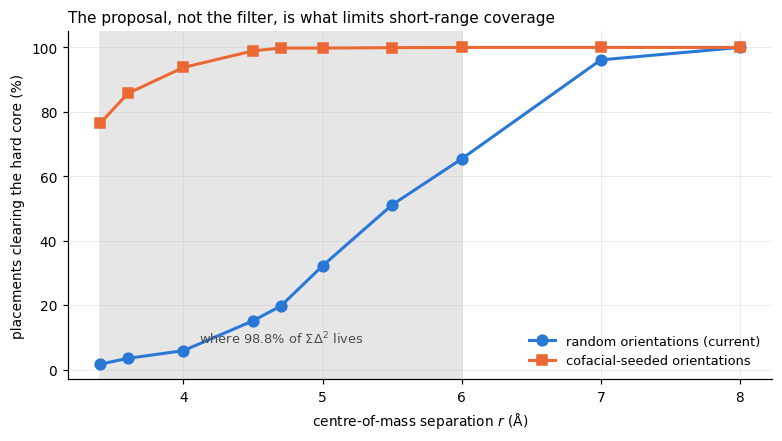

In [24]:
fig, ax = plt.subplots(figsize=(7.0, 3.9), constrained_layout=True)

ax.plot(probe, 100 * rate_random, "o-", color=C_CLUSTER, lw=2, ms=7,
        label="random orientations (current)")
ax.plot(probe, 100 * rate_cofacial, "s-", color=C_MC, lw=2, ms=7,
        label="cofacial-seeded orientations")
ax.axvspan(3.4, 6.0, color="0.9", zorder=0)
ax.annotate("where 98.8% of $\\Sigma\\Delta^2$ lives", xy=(4.7, 8), fontsize=8.5,
            color="0.3", ha="center")
ax.set_xlabel("centre-of-mass separation $r$ ($\\mathrm{\\AA}$)")
ax.set_ylabel("placements clearing the hard core (%)")
ax.set_title("The proposal, not the filter, is what limits short-range coverage",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.set_ylim(-3, 105)
plt.show()

**At 3.6 Å a random orientation clears the hard core 2.9% of the time; a cofacial-seeded
one clears it 84%.** Nearly 30×. And the compact-trimer puzzle from §5 resolves as
arithmetic: a trimer needs all three pairs to clear simultaneously, `0.21³ ≈ 0.9%`, against
the 1.7% observed.

So **`trimer_max_com_distance` never caused the three-body scarcity** and tightening it
cannot cure it. Worse, it is not a free knob — trimers supply 87% of all pair labels, so a
hard cap at 8 Å would remove 61% of the dataset's pair labels, cut the 9–15 Å shell from
624 to 85 pairs, and empty the >15 Å shell entirely, in exchange for a term worth
0.021 kcal/mol. §3 showed the MC is *more* tail-heavy than the pilot, so that is precisely
the coverage worth keeping.

**Four findings, one cause.** The thin 3.4–5 Å shell (§2), the parallel-displaced gap (§4),
the 1.7% compact trimers (§5), and the flat-versus-bimodal `|b|` mismatch (§3) are all the
same statement: *uniform orientations are incompatible with close approach*. Position and
orientation are coupled by the hard core, so they have to be proposed jointly.

## 7. Recommended production settings

Section 6 changes what to recommend. The single high-value change is **motif-seeded joint
sampling of position and orientation**; the radial knobs are secondary, and one of them
should explicitly *not* be touched.

### The change that matters — now implemented

`asmcmc/data_preparation/proposals.py` replaces "uniform orientation, then reject on clash"
with a **mixture of motif-seeded proposals**, enabled by
`SamplingSettings(orientation_sampling="motif")` or `--orientation-sampling motif`:

| component | geometry | why |
|---|---|---|
| `stacked_tight` | normals aligned, slip ≤ 2 Å | Covers cofacial (slip 0) and PD (slip 1.6) as one family. Cofacial is the scarce motif, n=13. |
| `stacked_wide` | normals aligned, slip ≤ 5 Å | The far-slipped region, Δ rms 2.04 — where the baseline is worst. |
| `t_shaped` | normals perpendicular, `r ∈ [4.2, 6.5] Å` | Geometrically impossible much below 4.5 Å, so it needs its own radial window. |
| **`uniform` (defensive)** | current behaviour, full range | Keeps support everywhere and bounds the importance weights. **Do not drop this.** |

Motif geometry is *derived* from the Cacelli minima via
`asmcmc.utils.validation.load_cacelli_dimers`, not hardcoded, so it cannot drift from what
`dimer_benchmark` scores a potential against.

Measured effect on a dimer draw: pairs landing inside 5 Å go from **2.7% to 36.7%**, and
the median separation from 12.0 Å to 5.3 Å.

**Every motif frame records `log_q`**, the mixture density at the geometry actually written
out. With a mixture this far from uniform that is what keeps the weighting decision
deferrable to fit time rather than baked into an expensive artifact — the MLIP budget is
spent once, but the fit's weighting will be revisited many times. The mixture component is
redrawn on every clash retry, so the realised density is `q(x)·1[no clash]/Z` for a single
global `Z` that cancels from all relative weights.

### Radial knobs — secondary

| change | from → to | why |
|---|---|---|
| `trimer_max_com_distance` | 15.0 → **leave at 15.0** | **Reversed.** It never caused the three-body scarcity (§6), and capping it at 8 Å would delete 61% of pair labels and empty the >15 Å shell for a 0.021 kcal/mol term. |
| mixture upper cap | 6.0 → **smooth bump** | The cap is a 5.9× density discontinuity at 6 Å (the n=26 notch). An `r²`-times-Gaussian proposal removes it with no truncation anywhere. |
| `compact_probability` | 0.70 → **keep for now** | Raising it pushes *against* the hard-core filter rather than past it — the extra draws are rejected and redrawn. Revisit once motif seeding makes short-range proposals viable. |
| `trimer_fraction` | 0.70 → **keep, eyes open** | Dimers are the *cheaper* pair label (1.00 vs 1.33 MLIP calls each, §2), so 0.7 costs ~33% overhead per label and buys only the 0.021 kcal/mol three-body term. Kept for continuity with this pilot; revisit if pair labels become the binding cost. |

**What not to change:** `min_atom_distance` 2.4 Å and `rigid=True` both held up — the hard
core was never breached and the rigid monomer reference is exact. And `max_com_distance`
stays a **hard** 15 Å: it encodes a real model boundary (`nl_radius`, the descriptor
cutoff), not a guess about where information lives. That is the general rule this analysis
converged on — *a hard limit where the model structurally has a boundary; a distribution
wherever you are guessing.*

### Why this direction is safe

Shape mismatch is recoverable after the fact; truncation is not. Reweighting the pilot's
pairs to the MC census gives **ESS ≈ 72%** with a max/median weight of 4.0 and no empty
bins — because the pilot never truncated. A motif mixture with a defensive uniform
component preserves that property; a hard cap destroys it, and no reweighting brings back a
region that was never sampled.

### Next step, and caveats

**The default is still `orientation_sampling="uniform"`.** It stays that way until a second
small pilot (~200 configs, `--orientation-sampling motif`) is compared against this one on:
hard-core acceptance, the corrected motif counts (cofacial should rise well above n=13), the
3.4–5 Å pair fraction, and the spread of `log_q` weights — if max/median exceeds roughly an
order of magnitude, `uniform_weight` is set too low.

Everything here is read off a single 500-frame pilot, and the counts behind the sharpest
findings are small (cofacial n=13, far-slipped n=30). The mixture weights in
`default_mixture` are a starting point chosen from these numbers, not an optimum.